# 7장 스타일 전이 (Style transfer)

* "부록3 매트플롯립 입문"에서 한글 폰트를 올바르게 출력하기 위한 설치 방법을 설명했다. 설치 방법은 다음과 같다.

In [ ]:
# 한글 폰트 설치

!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [ ]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# Colab, Linux
# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

# Window
# font_name = "NanumBarunGothic"

# Mac
# font_name = "AppleGothic"

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [7]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name  # window font

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [8]:
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Tensor 함수 정의

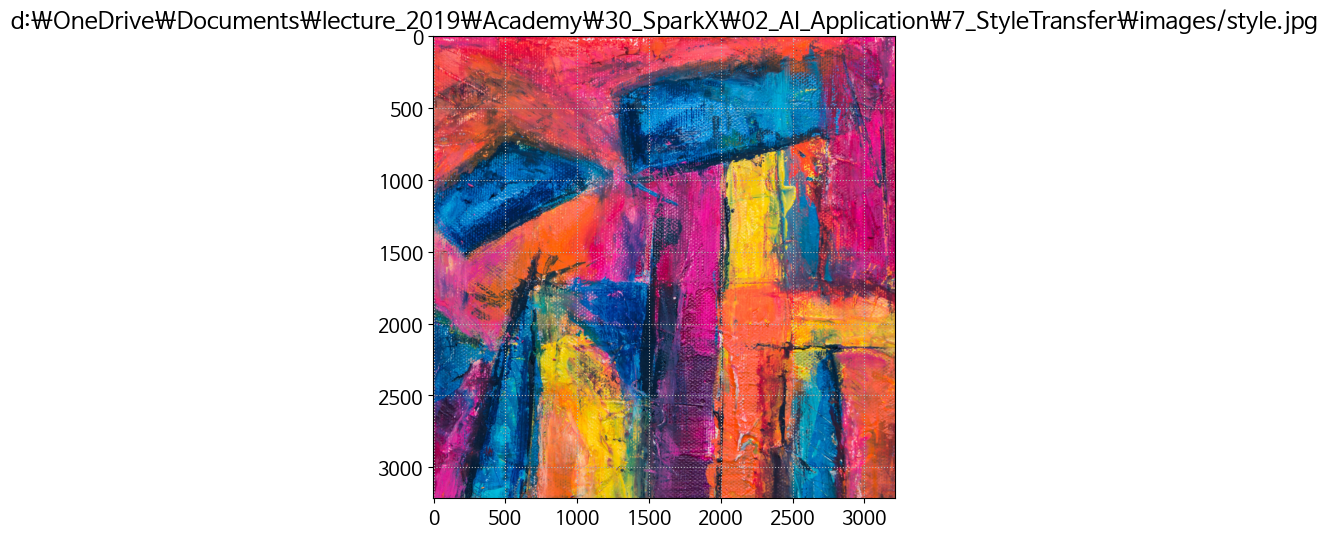

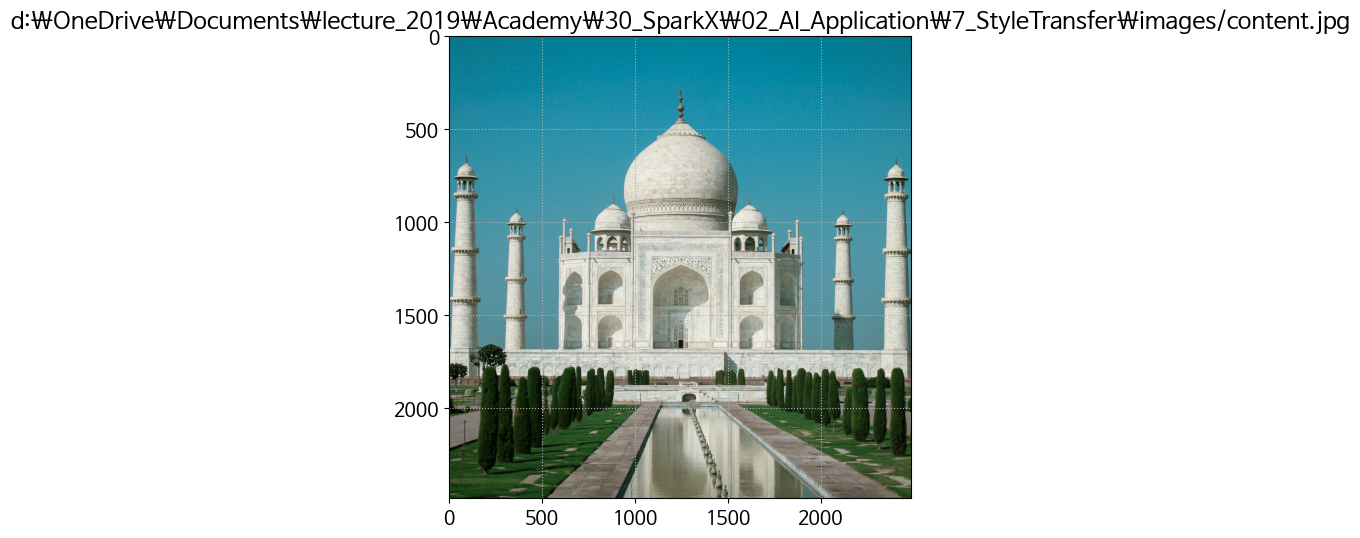

In [111]:
def image_to_tensor(image_filepath, image_dimension=128):
    img = Image.open(image_filepath).convert('RGB')
    
    # display image to check 
    plt.figure()
    plt.title(image_filepath)
    plt.imshow(img)
    
    if max(img.size) <= image_dimension:
        img_size = max(img.size)
    else:
        img_size = image_dimension
  
    torch_transformation = torchvision.transforms.Compose([
        torchvision.transforms.Resize(img_size),
        torchvision.transforms.ToTensor()
    ])
  
    img = torch_transformation(img).unsqueeze(0)
  
    return img.to(device, torch.float)

style_image = image_to_tensor(os.path.join(os.getcwd(), "images/style.jpg"))
content_image = image_to_tensor(os.path.join(os.getcwd(),"images/content.jpg"))

## Define gram matrix

In [112]:
def gram_matrix(ip):
    num_batch, num_channels, height, width = ip.size()
    feats = ip.view(num_batch * num_channels, width * height)
    gram_mat = torch.mm(feats, feats.t()) 
    return gram_mat.div(num_batch * num_channels * width * height) # Different layers in a CNN produce feature maps of different sizes.

## Pretrained model

In [113]:
weights = torchvision.models.VGG19_Weights.DEFAULT
vgg19_model = torchvision.models.vgg19(weights = weights).to(device)
print(vgg19_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [114]:
vgg19_model = vgg19_model.features
print(vgg19_model)                                                            

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [115]:
for param in vgg19_model.parameters():
    param.requires_grad_(False)

## refine model for this task

### change maxpool layers to avgpool

In [116]:
conv_indices = []

for i in range(len(vgg19_model)):
    if vgg19_model[i]._get_name() == 'MaxPool2d':
        vgg19_model[i] = nn.AvgPool2d(kernel_size=vgg19_model[i].kernel_size, 
                                      stride=vgg19_model[i].stride, 
                                      padding=vgg19_model[i].padding)
    if vgg19_model[i]._get_name() == 'Conv2d':
        conv_indices.append(i)
        
conv_indices = dict(enumerate(conv_indices, start = 1))
print("vgg19_model = \n", vgg19_model)
print(conv_indices)

vgg19_model = 
 Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): AvgPool2d(kernel_size=2, stride=2, padding=0)
  

### clip until the last relevant layer

In [117]:
layers = {1: 's', 2: 's', 3: 's', 4: 'sc', 5: 's'} #  style loss, content loss layers  

### nn.ModuleList vs nn.Sequential

In [118]:
## nn.ModuleList

import torch
import torch.nn as nn

class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(10, 20),
            nn.Linear(20, 30),
            nn.Linear(30, 40)
        ])

    def forward(self, x):
        for layer in self.layers:  # Must manually apply each layer
            x = layer(x)
        return x

model = CustomModel()
x = torch.randn(1, 10)
output = model(x)
print(output.shape)  # torch.Size([1, 40])


torch.Size([1, 40])


In [119]:
## nn.Sequential

model = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 30),
    nn.ReLU(),
    nn.Linear(30, 40)
)

x = torch.randn(1, 10)
output = model(x)  # No need to manually loop over layers
print(output.shape)  # torch.Size([1, 40])


torch.Size([1, 40])


In [120]:
vgg_layers = nn.ModuleList(vgg19_model)
vgg_layers

ModuleList(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (19): Conv2d(256

In [121]:
display(conv_indices)

{1: 0,
 2: 2,
 3: 5,
 4: 7,
 5: 10,
 6: 12,
 7: 14,
 8: 16,
 9: 19,
 10: 21,
 11: 23,
 12: 25,
 13: 28,
 14: 30,
 15: 32,
 16: 34}

In [122]:
last_layer_idx = conv_indices[max(layers.keys())]
vgg_layers_trimmed = vgg_layers[:last_layer_idx+1]
vgg_layers_trimmed

ModuleList(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [123]:

neural_style_transfer_model = nn.Sequential(*vgg_layers_trimmed) # ModuleList
print(neural_style_transfer_model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


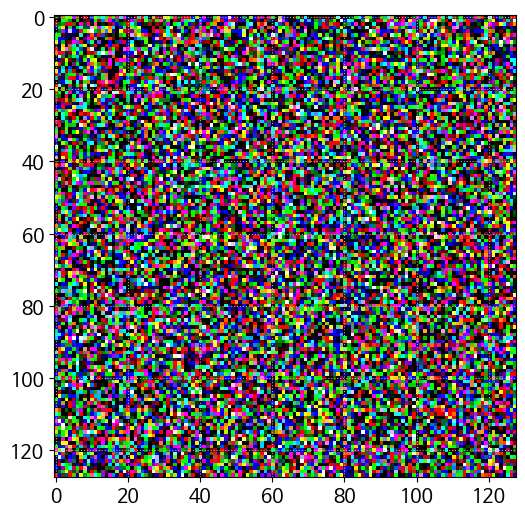

In [ ]:
# initialize as the content image
# ip_image = content_image.clone()
# initialize as random noise:
ip_image = torch.randn(content_image.data.size(), device=device)

plt.figure()
plt.imshow(ip_image.squeeze(0).cpu().detach().numpy().transpose(1,2,0).clip(0,1))
plt.show()

In [128]:
layers.keys()
layers

{1: 's', 2: 's', 3: 's', 4: 'sc', 5: 's'}

### Gram matrix

In [101]:
ip_image.requires_grad_()

tensor([[[[0.9685, 0.5018, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [0.4308, 0.9483, 0.8263,  ..., 0.9796, 1.0000, 0.9929],
          [1.0000, 0.6389, 1.0000,  ..., 1.0000, 0.8779, 1.0000],
          ...,
          [0.9839, 1.0000, 0.7147,  ..., 0.4384, 0.3309, 0.5805],
          [1.0000, 0.6127, 1.0000,  ..., 0.2926, 0.2314, 0.3630],
          [0.6824, 1.0000, 0.7322,  ..., 0.1382, 0.1579, 0.3245]],

         [[0.0000, 0.2755, 0.0826,  ..., 0.2292, 0.4039, 0.0000],
          [0.2891, 0.2333, 0.3617,  ..., 0.4678, 0.0531, 0.3399],
          [0.2574, 0.2820, 0.2812,  ..., 0.3745, 0.4138, 0.2506],
          ...,
          [0.1301, 0.3148, 0.3671,  ..., 0.1476, 0.1007, 0.1166],
          [0.2558, 0.5799, 0.3098,  ..., 0.1776, 0.1467, 0.1793],
          [0.1558, 0.2935, 0.4051,  ..., 0.1051, 0.1772, 0.0319]],

         [[0.0035, 0.2902, 0.4329,  ..., 0.3850, 0.4592, 0.4918],
          [0.0298, 0.2934, 0.4216,  ..., 0.2762, 0.7895, 0.3405],
          [0.0135, 0.6228, 0.0931,  ..., 0

In [130]:
def gram_matrix(input_tensor):  
    batch, channels, height, width = input_tensor.size()  
    features = input_tensor.view(channels, height * width)  
    gram = torch.mm(features, features.t())  
    return gram  

epoch number 50
style loss = 1549675.625, content loss = 6.785552978515625


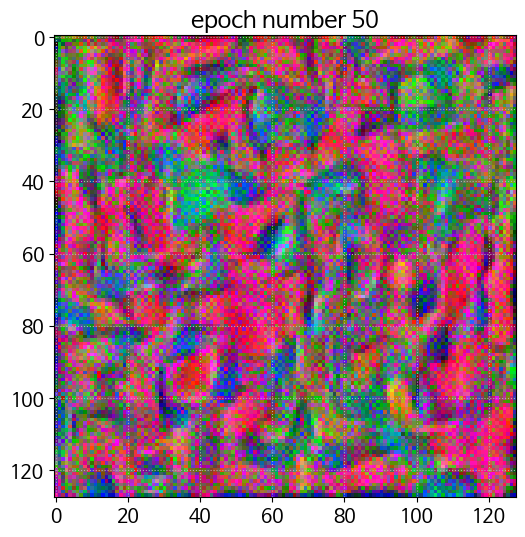

epoch number 100
style loss = 405820.21875, content loss = 6.825432777404785


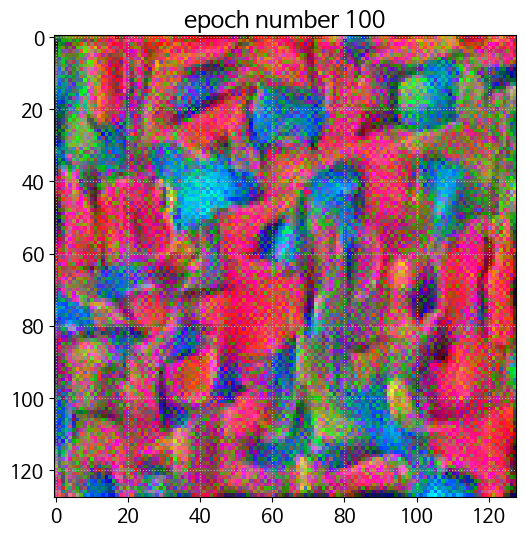

epoch number 150
style loss = 175832.9375, content loss = 6.8693928718566895


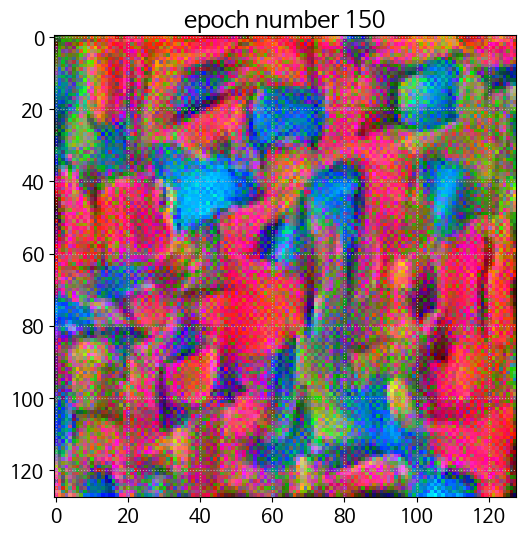

epoch number 200
style loss = 107132.3125, content loss = 6.882870674133301


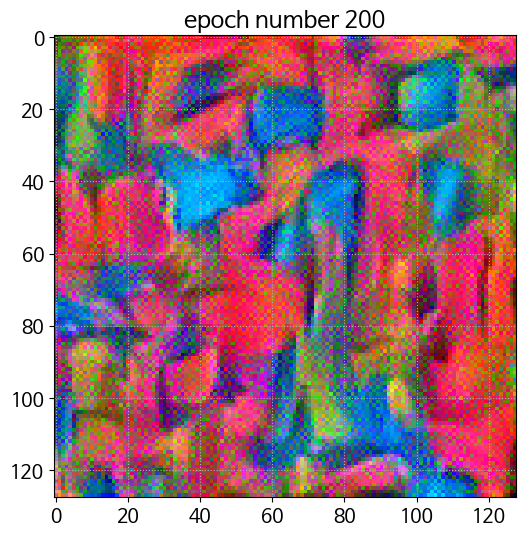

epoch number 250
style loss = 74419.546875, content loss = 6.888459205627441


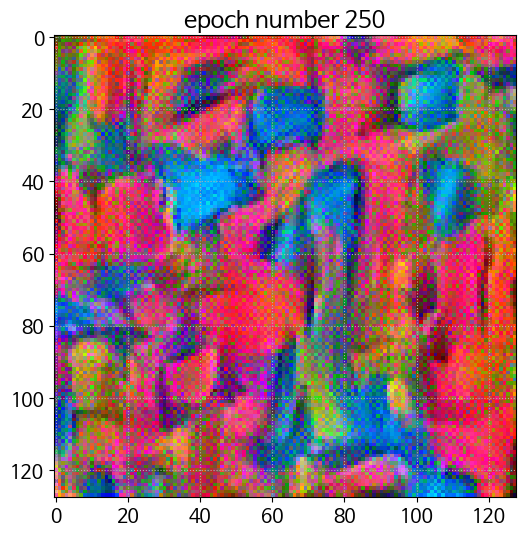

epoch number 300
style loss = 55290.75, content loss = 6.892725944519043


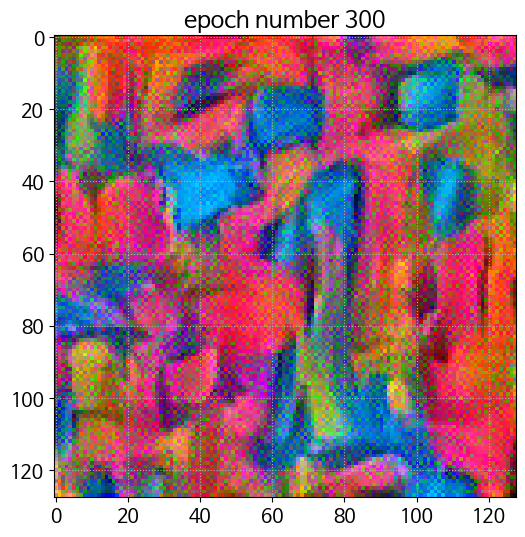

epoch number 350
style loss = 42981.4296875, content loss = 6.9012837409973145


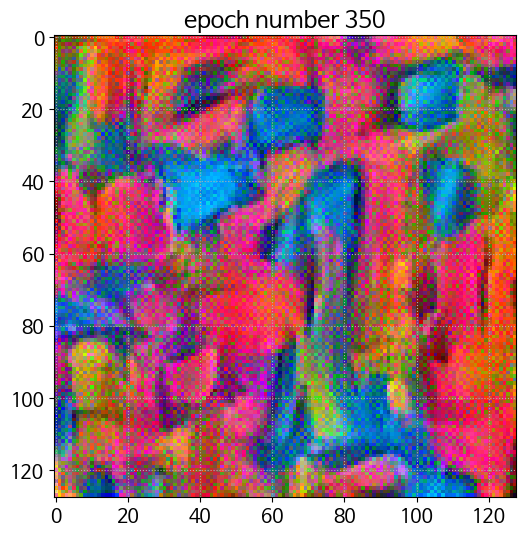

epoch number 400
style loss = 34623.1328125, content loss = 6.909946441650391


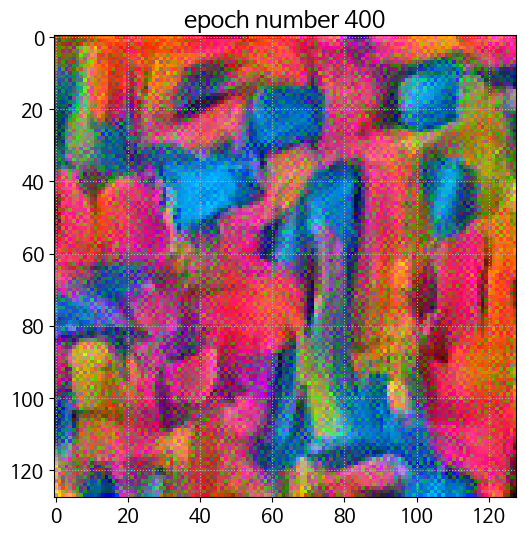

epoch number 450
style loss = 28619.6796875, content loss = 6.916177749633789


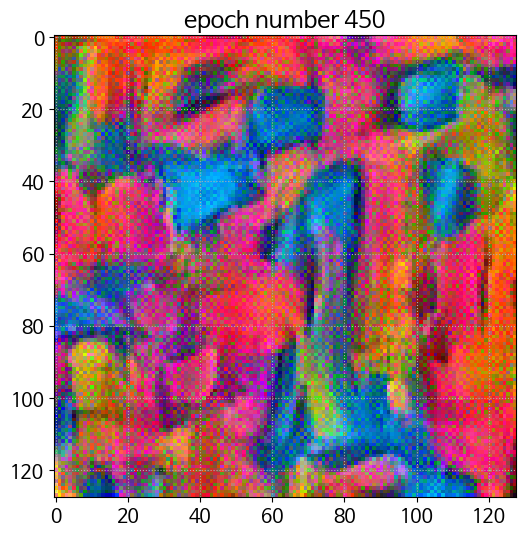

epoch number 500
style loss = 24175.734375, content loss = 6.9187116622924805


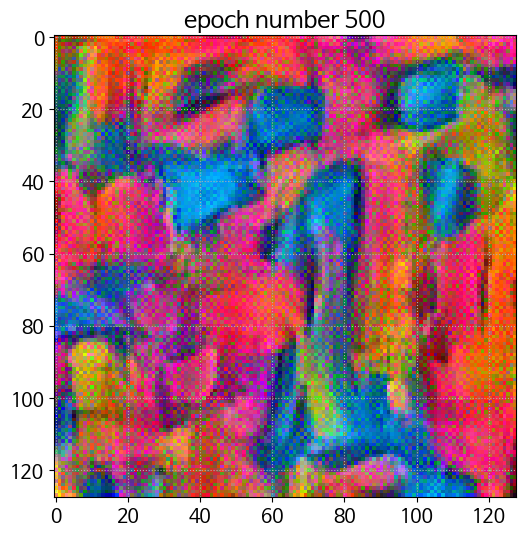

epoch number 550
style loss = 20794.16015625, content loss = 6.919804573059082


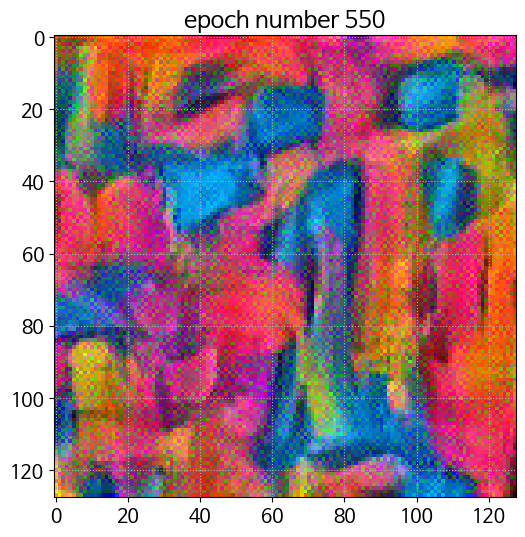

epoch number 600
style loss = 18158.138671875, content loss = 6.921343803405762


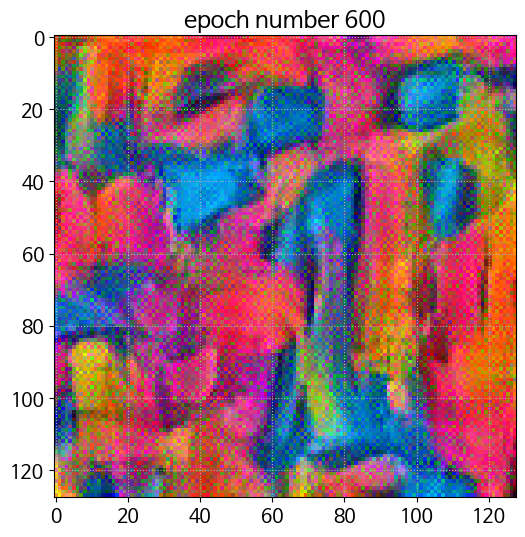

epoch number 650
style loss = 16043.8134765625, content loss = 6.921295642852783


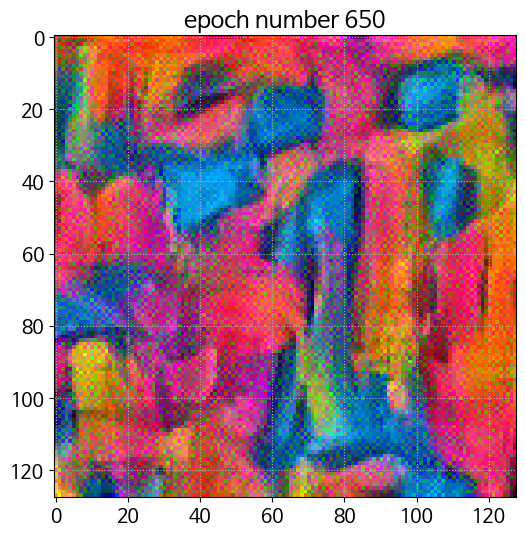

epoch number 700
style loss = 14302.953125, content loss = 6.920389652252197


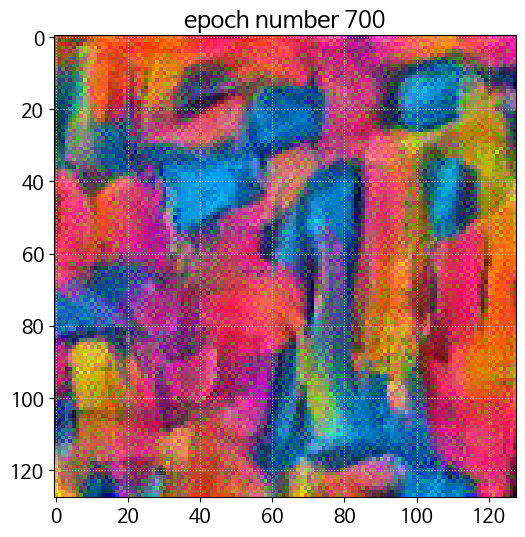

epoch number 750
style loss = 12846.0888671875, content loss = 6.9187140464782715


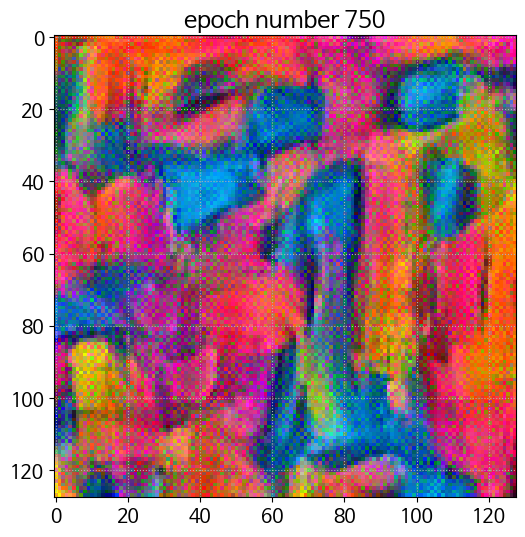

epoch number 800
style loss = 11612.380859375, content loss = 6.916598796844482


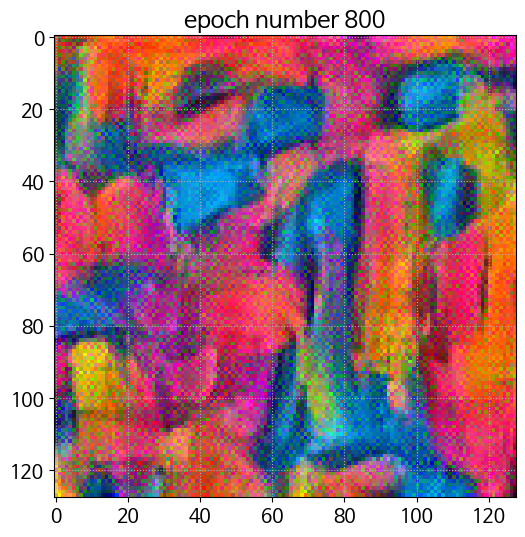

epoch number 850
style loss = 10563.580078125, content loss = 6.914859771728516


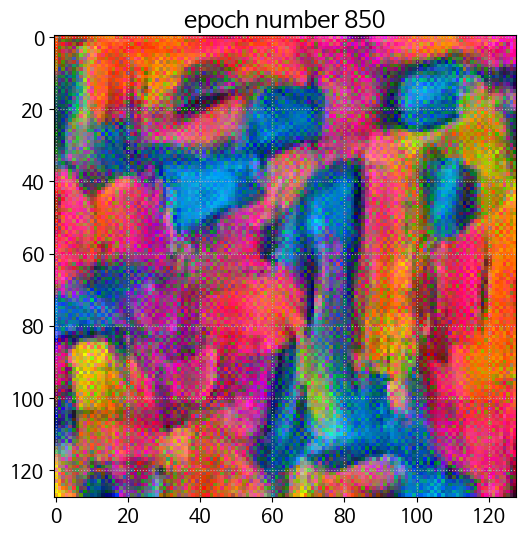

epoch number 900
style loss = 9662.107421875, content loss = 6.914201736450195


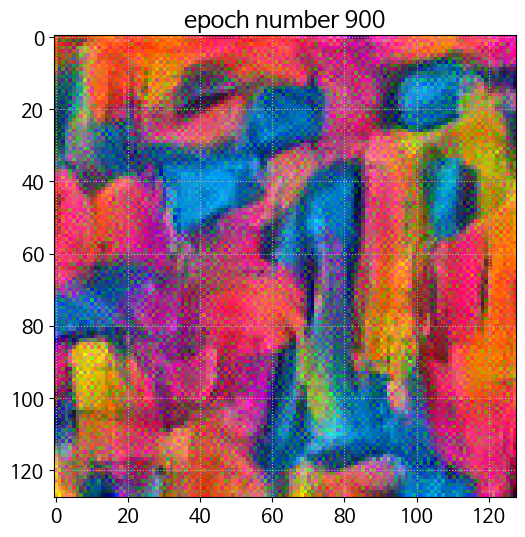

epoch number 950
style loss = 8869.5400390625, content loss = 6.914239406585693


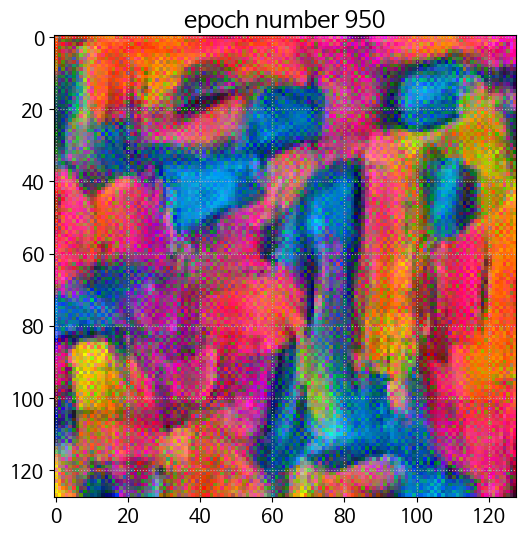

epoch number 1000
style loss = 8171.505859375, content loss = 6.9142255783081055


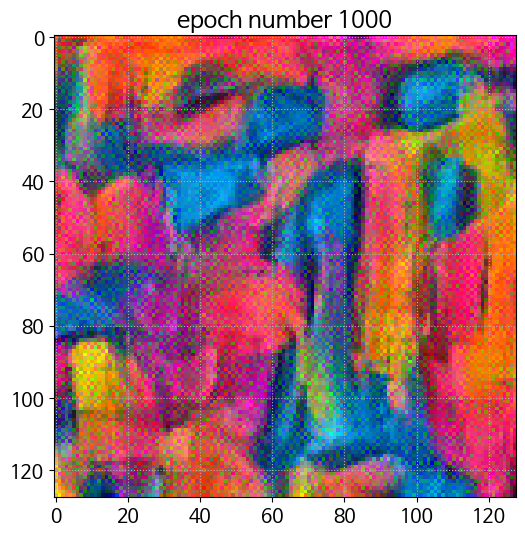

In [ ]:
num_epochs=1000
wt_style=1e6 #
wt_content=1  
style_losses = []
content_losses = []
optimizer = optim.Adam([ip_image.requires_grad_()], lr=0.1) # requires_grad=False => True

for curr_epoch in range(1, num_epochs+1): 
     
    ip_image.data.clamp_(0, 1) # Clamps all elements in input into the range [ min, max ].
    optimizer.zero_grad()
    epoch_style_loss = 0
    epoch_content_loss = 0

    for k in layers.keys(): # layers = {1: 's', 2: 's', 3: 's', 4: 'sc', 5: 's'} 
        if 'c' in layers[k]:
            target = neural_style_transfer_model[:conv_indices[k]+1](content_image).detach()
            ip = neural_style_transfer_model[:conv_indices[k]+1](ip_image)
            epoch_content_loss += torch.nn.functional.mse_loss(ip, target)
        if 's' in layers[k]:
            target = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](style_image)).detach()
            ip = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](ip_image))
            epoch_style_loss += torch.nn.functional.mse_loss(ip, target)

    epoch_style_loss *= wt_style
    epoch_content_loss *= wt_content
    total_loss = epoch_style_loss + epoch_content_loss
    # total_loss = epoch_style_loss*wt_style + epoch_content_loss*wt_content
    total_loss.backward()
    optimizer.step()

    if curr_epoch % 50 == 0:
        print(f"epoch number {curr_epoch}")
        print(f"style loss = {epoch_style_loss}, content loss = {epoch_content_loss}")
        plt.figure()
        plt.title(f"epoch number {curr_epoch}")
        plt.imshow(ip_image.data.clamp_(0, 1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))
        plt.show()
        # style_losses += [epoch_style_loss]
        # content_losses += [epoch_content_loss]
        style_losses.append(epoch_style_loss.item())
        content_losses.append(epoch_content_loss.item())    

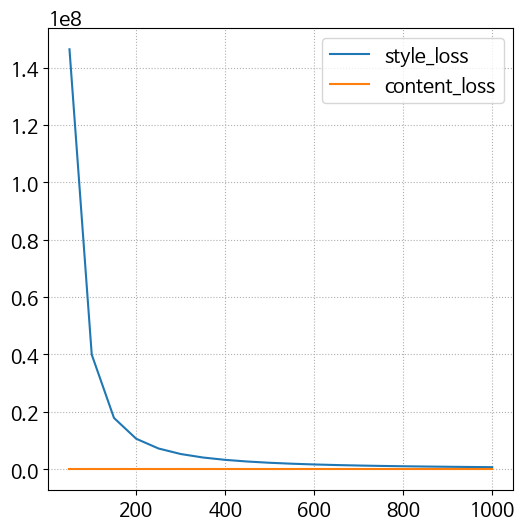

In [110]:
plt.plot(range(50, 1000+1, 50), torch.tensor(style_losses), label='style_loss')
plt.plot(range(50, 1000+1, 50), torch.tensor(content_losses), label='content_loss')
plt.legend()
plt.show()